# **Homework 4 - Numerov Method**
## CHEM 5581 - Intro Quantum Chemistry
### *Samuel Arnold*
### *9/22/26*
***

## 1.) 

$$\psi = e^{-\alpha x^2 / 2} f(x)$$

$$\psi' = -\alpha x e^{-\alpha x^2 / 2} f(x) + f'(x)e^{-\alpha x^2 / 2}$$

$$\psi'' = [-\alpha e^{-\alpha x^2 / 2} + (\alpha^2 x^2 e^{-\alpha x^2 / 2})]f(x) + f'(x) (-\alpha x e^{-\alpha x^2 / 2}) + [f'(x)(-\alpha x e^{-\alpha x^2 / 2}) + e^{-\alpha x^2 / 2} f''(x)]$$

$$\psi'' = e^{-\alpha x^2 / 2}[f''(x) - 2\alpha x f'(x) + (\alpha^2 x^2 - \alpha)f(x)]$$

## 2.) 

$$\psi_2 = (c_0 + c_2 x^2)e^{-\alpha x^2 /2}$$

Using the recursion relation:

$$c_{n+2} = \frac{2\alpha(n-v)}{(n+1)(n+2)}c_n$$

For $v=2$, $n=0$

$$c_2 = \frac{2\alpha(0-2)}{(1)(2)}c_0 = -2 \alpha c_0$$

Substituting back into original equation:

$$\psi_2 = (c_0 + (-2 \alpha c_0) x^2)e^{-\alpha x^2 /2}$$

$$\psi_2 = c_0 ( 1 - 2 \alpha  x^2)e^{-\alpha x^2 /2}$$


Normalize:

$$c_0^2 \int_{-\infty}^{\infty} ( 1 - 2 \alpha  x^2)^2e^{-\alpha x^2} dx = 1$$

$$c_0^2 \int_{-\infty}^{\infty} ( 1 - 4 \alpha x^2 + 4 \alpha^2 x^4)e^{-\alpha x^2} dx = 1$$

Breaking into seperate integrals:

$$c_0^2 \left(\int_{-\infty}^{\infty} e^{-\alpha x^2} dx - 4 \alpha \int_{-\infty}^{\infty} x^2 e^{-\alpha x^2} dx + 4 \alpha^2 \int_{-\infty}^{\infty} x^4 e^{-\alpha x^2} dx \right)= 1$$

Using standard Gaussian integrals:

$$c_0^2 \left[ \sqrt{\frac{\pi}{\alpha}} -4\alpha \left( \frac{1}{2 \alpha} \sqrt{\frac{\pi}{a}} \right) + 4\alpha^2 \left(\frac{3}{4\alpha^2} \sqrt{\frac{\pi}{\alpha}} \right)\right]= 1$$

$$c_0^2 \sqrt{\frac{\pi}{\alpha}} (1-2+3) = 1$$

$$2c_0^2 \sqrt{\frac{\pi}{\alpha}} = 1$$

$$c_0^2 = \frac{1}{2} \sqrt{\frac{a}{\alpha}}$$

$$c_0 = \left(\frac{\alpha}{4\pi} \right)^{1/4}$$

$$c_2 = -2\alpha \left(\frac{\alpha}{4\pi} \right)^{1/4}$$

Therefore:

$$\psi_2(x) = \left(\frac{\alpha}{4\pi} \right)^{1/4} ( 1 - 2 \alpha  x^2)e^{-\alpha x^2 /2}$$

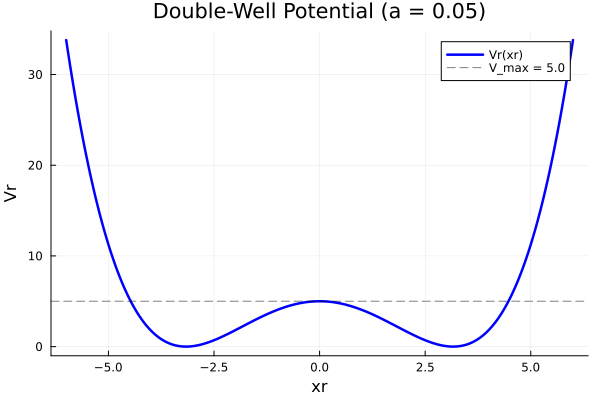

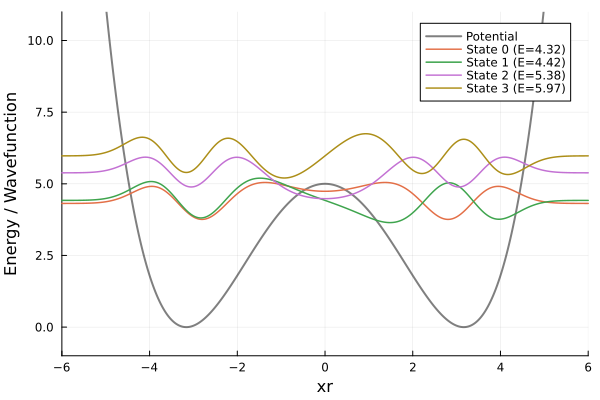

--- Found Eigenvalues (Er < 10) ---
State 0: Er = 4.3155
State 1: Er = 4.4215
State 2: Er = 5.3828
State 3: Er = 5.9746
State 4: Er = 6.8332
State 5: Er = 7.7437
State 6: Er = 8.7369
State 7: Er = 9.7949


In [ ]:
using Plots

# 1. Define the dimensionless potential
const a = 0.05
V_r(x_r) = 1 / (4*a) - x_r^2 + a * x_r^4

# --- Part c: Plotting the Potential ---
x_vals = range(-6.0, 6.0, length=400)
p1 = plot(
    x_vals, 
    V_r.(x_vals), 
    label="Vr(xr)", 
    linewidth=2.5, 
    color=:blue,
    title="Double-Well Potential (a = 0.05)", 
    xlabel="xr", 
    ylabel="Vr"
)
hline!([5.0], line=(:dash, :black, 0.5), label="V_max = 5.0")
display(p1)

# --- Part d: Numerov Integration Setup ---
# We set up a grid from -x_max to +x_max
const x_max = 6.5
const N = 2000
const dx = (2 * x_max) / N
const x = collect(range(-x_max, x_max, length=N+1))

# Numerov step function
function numerov_integrate(E)
    psi = zeros(N+1)
    # Boundary conditions at the far left edge
    psi[1] = 0.0
    psi[2] = 1e-6 # Small seed value
    
    # Precompute k^2 term: 2*(E - V)
    k2 = 2.0 .* (E .- V_r.(x))
    fac = (dx^2) / 12.0
    
    for i in 2:N
        term_prev = (1.0 + fac * k2[i-1]) * psi[i-1]
        term_curr = 2.0 * (1.0 - 5.0 * fac * k2[i]) * psi[i]
        denom = 1.0 + fac * k2[i+1]
        psi[i+1] = (term_curr - term_prev) / denom
    end
    return psi
end

# Find the final boundary value mismatch at +x_max to evaluate eigenvalues
function boundary_mismatch(E)
    psi = numerov_integrate(E)
    return psi[end]
end

# Simple secant-method root finder to locate accurate energy states
function find_eigenvalue(E_guess, dE=0.01; max_iter=20)
    E0 = E_guess
    E1 = E_guess + dE
    f0 = boundary_mismatch(E0)
    
    for _ in 1:max_iter
        f1 = boundary_mismatch(E1)
        if abs(f1 - f0) < 1e-12 break end
        E_next = E1 - f1 * (E1 - E0) / (f1 - f0)
        E0, E1 = E1, E_next
        f0 = f1
    end
    return E1
end

# Scan energy range from E=0 to E=10 to find where mismatch flips signs
E_range = range(0.0, 10.0, length=400)
mismatches = [boundary_mismatch(E) for E in E_range]

eigenvalues = Float64[]
for i in 1:(length(E_range)-1)
    # Check for sign change indicating a zero-crossing root
    if mismatches[i] * mismatches[i+1] < 0
        E_guess = (E_range[i] + E_range[i+1]) / 2.0
        E_exact = find_eigenvalue(E_guess)
        if isempty(eigenvalues) || abs(eigenvalues[end] - E_exact) > 1e-4
            push!(eigenvalues, E_exact)
        end
    end
end

# Print the discovered energy levels
println("--- Found Eigenvalues (Er < 10) ---")
for (idx, E) in enumerate(eigenvalues)
    println("State $(idx-1): Er = ", round(E, digits=4))
end

# --- Plot the lowest Wavefunctions ---
p2 = plot(
    x_vals, 
    V_r.(x_vals), 
    label="Potential", 
    color=:black, 
    alpha=0.5, 
    linewidth=2,
    xlims=(-6, 6), 
    ylims=(-1, 11), 
    xlabel="xr",
    ylabel="Energy / Wavefunction"
)

# Plot each valid state scaled visually to its baseline energy position
for (idx, E) in enumerate(eigenvalues[1:min(4, length(eigenvalues))])
    psi = numerov_integrate(E)
    # Normalize the wave function
    norm_factor = sqrt(sum(psi.^2) * dx)
    psi_norm = psi ./ norm_factor
    
    # Offset by baseline energy E for visual display clarity
    plot!(
        x, 
        E .+ 1.5 .* psi_norm, 
        label="State $(idx-1) (E=$(round(E, digits=2)))", 
        linewidth=1.5
    )
end
display(p2)
